<a href="https://colab.research.google.com/github/dev-yooillog/MAIN_QUEST/blob/main/Mini_Project3/Car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set(style='whitegrid')


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
file_path = '/content/drive/MyDrive/Colab Notebooks/audi.xls'
carprice = pd.read_csv(file_path)

In [6]:
carprice.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [7]:
carprice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10668 non-null  object 
 1   year          10668 non-null  int64  
 2   price         10668 non-null  int64  
 3   transmission  10668 non-null  object 
 4   mileage       10668 non-null  int64  
 5   fuelType      10668 non-null  object 
 6   tax           10668 non-null  int64  
 7   mpg           10668 non-null  float64
 8   engineSize    10668 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 750.2+ KB


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()

In [10]:
carprice['transmission'] = le.fit_transform(carprice['transmission'])

In [11]:
carprice.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,1,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,0,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,1,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,0,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,1,1998,Petrol,145,49.6,1.0


In [12]:
carprice = pd.get_dummies(carprice, columns=['fuelType'])

In [13]:
carprice.head()

,model,year,price,transmission,mileage,tax,mpg,engineSize,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol
0,A1,2017,12500,1,15735,150,55.4,1.4,False,False,True
1,A6,2016,16500,0,36203,20,64.2,2.0,True,False,False
2,A1,2016,11000,1,29946,30,55.4,1.4,False,False,True
3,A4,2017,16800,0,25952,145,67.3,2.0,True,False,False
4,A3,2019,17300,1,1998,145,49.6,1.0,False,False,True


### model 컬럼 Label Encoding

In [14]:
carprice['model'] = le.fit_transform(carprice['model'])

In [15]:
carprice.head()

,model,year,price,transmission,mileage,tax,mpg,engineSize,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol
0,0,2017,12500,1,15735,150,55.4,1.4,False,False,True
1,5,2016,16500,0,36203,20,64.2,2.0,True,False,False
2,0,2016,11000,1,29946,30,55.4,1.4,False,False,True
3,3,2017,16800,0,25952,145,67.3,2.0,True,False,False
4,2,2019,17300,1,1998,145,49.6,1.0,False,False,True


### 데이터 분포

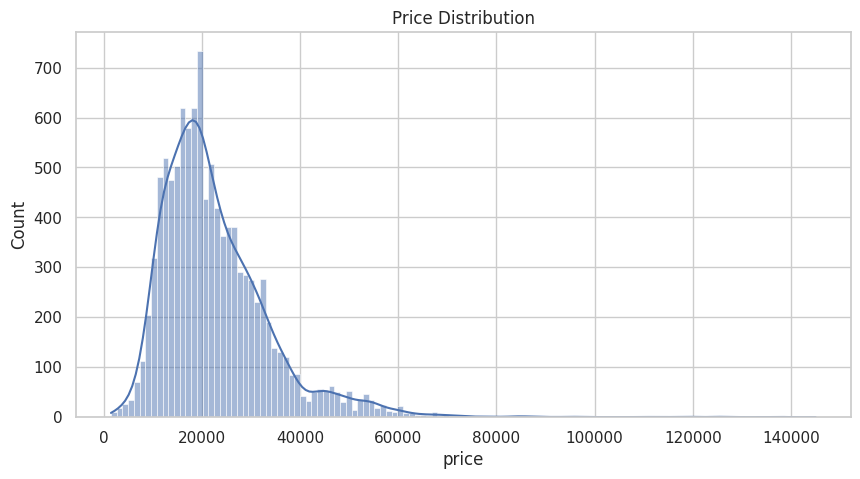

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(carprice['price'], kde=True)
plt.title('Price Distribution')
plt.show()

In [17]:
carprice['log_price'] = np.log1p(carprice['price'])

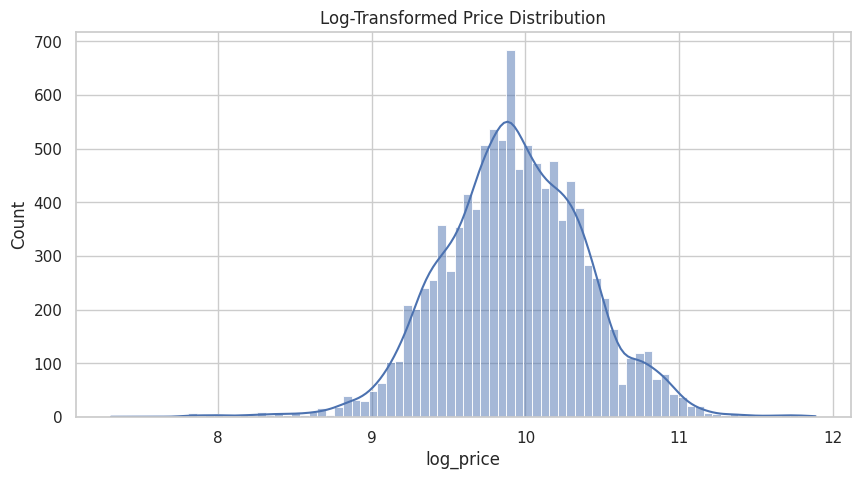

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(carprice['log_price'], kde=True)
plt.title('Log-Transformed Price Distribution')
plt.show()

### 상관관계 분석

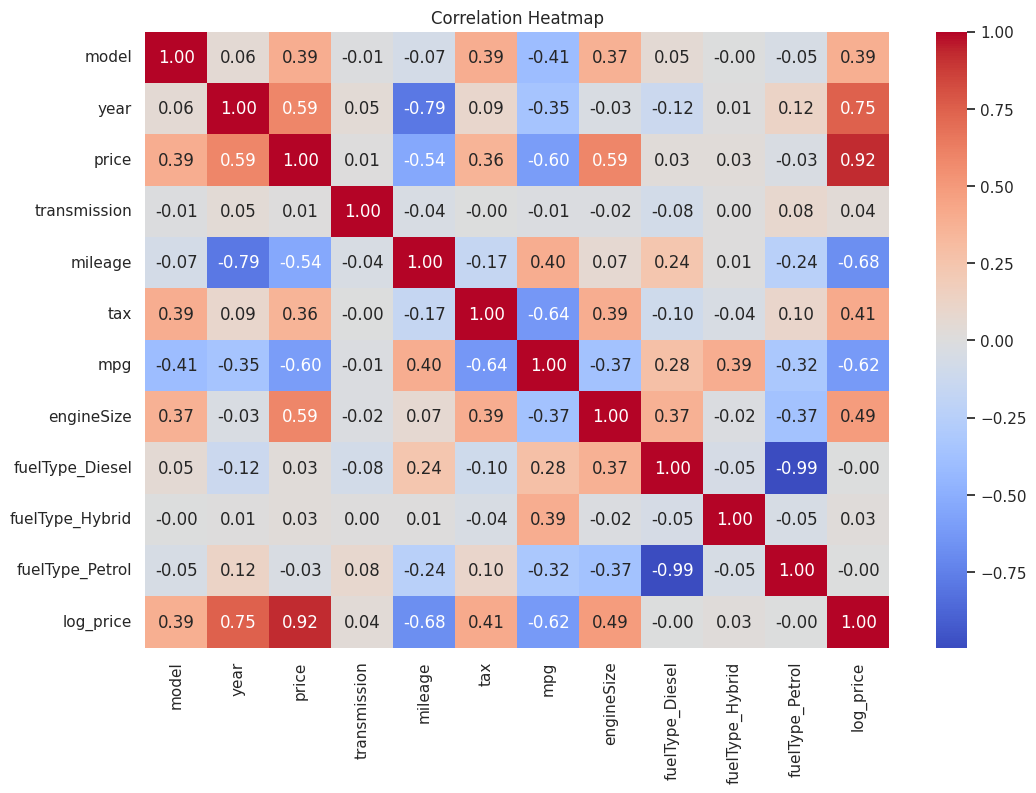

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(carprice.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### EDA

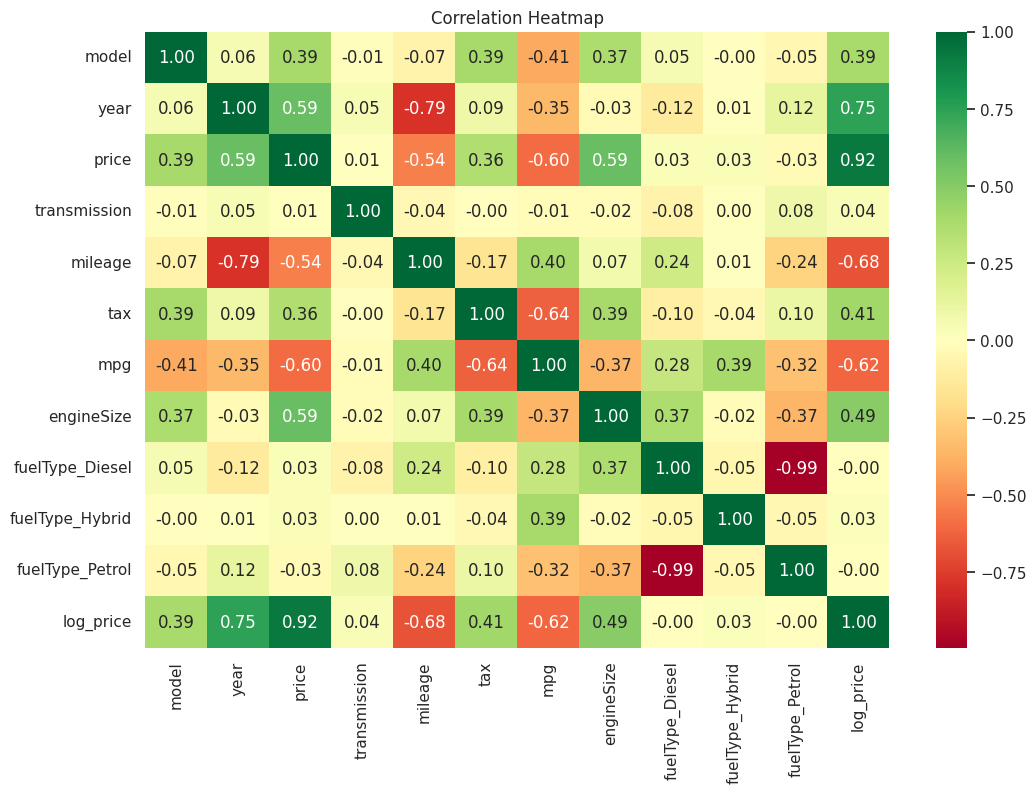

In [20]:
plt.figure(figsize=(12, 8))
corr = carprice.corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()